In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [10]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"akainth01","key":"ffe350ffc0e1b50efff7c8425f63c0e9"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d biaiscience/dogs-vs-cats -p /content

Dataset URL: https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats
License(s): DbCL-1.0
100% 817M/817M [00:05<00:00, 168MB/s]



In [5]:
!ls -lh /content

total 817M
-rw-r--r-- 1 root root 817M Sep 25  2019 dogs-vs-cats.zip
-rw-r--r-- 1 root root   65 May 23 04:43 kaggle.json
drwxr-xr-x 1 root root 4.0K May 21 13:32 sample_data


In [6]:
!unzip -o /content/dogs-vs-cats.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/train/dog.5499.jpg  
  inflating: /content/data/train/train/dog.55.jpg  
  inflating: /content/data/train/train/dog.550.jpg  
  inflating: /content/data/train/train/dog.5500.jpg  
  inflating: /content/data/train/train/dog.5501.jpg  
  inflating: /content/data/train/train/dog.5502.jpg  
  inflating: /content/data/train/train/dog.5503.jpg  
  inflating: /content/data/train/train/dog.5504.jpg  
  inflating: /content/data/train/train/dog.5505.jpg  
  inflating: /content/data/train/train/dog.5506.jpg  
  inflating: /content/data/train/train/dog.5507.jpg  
  inflating: /content/data/train/train/dog.5508.jpg  
  inflating: /content/data/train/train/dog.5509.jpg  
  inflating: /content/data/train/train/dog.551.jpg  
  inflating: /content/data/train/train/dog.5510.jpg  
  inflating: /content/data/train/train/dog.5511.jpg  
  inflating: /content/data/train/train/dog.5512.jpg  
  inflating: /content/data/train/tr

In [7]:
import os
os.listdir('/content/data')

['train', 'test']

In [8]:
from tensorflow import keras

# Train dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data/train',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data/test',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 25000 files belonging to 1 classes.
Found 12500 files belonging to 1 classes.


In [9]:
#normalize
def process(image,label):
    image=tf.cast(image/255. ,tf.float32)
    return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [10]:
#create cnn model
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 111ms/step - accuracy: 0.9988 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 1.3158e-25
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 1.0000 - loss: 3.7011e-13 - val_accuracy: 1.0000 - val_loss: 9.3302e-25
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 97ms/step - accuracy: 1.0000 - loss: 6.3691e-12 - val_accuracy: 1.0000 - val_loss: 8.3248e-25
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 1.0000 - loss: 1.1768e-16 - val_accuracy: 1.0000 - val_loss: 1.0491e-24
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 1.0000 - loss: 2.2360e-17 - val_accuracy: 1.0000 - val_loss: 1.5089e-24
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 1.0000 - loss: 1.1652e-16 - val_accuracy: 1.0000 - val_loss: 1.0774e-24
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 1.0000 - loss: 6.7243e-17 - val_accuracy: 1.0000 - val_loss: 9.0461e-25
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━

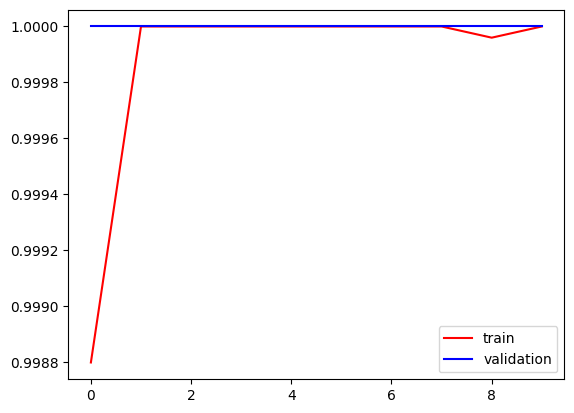

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

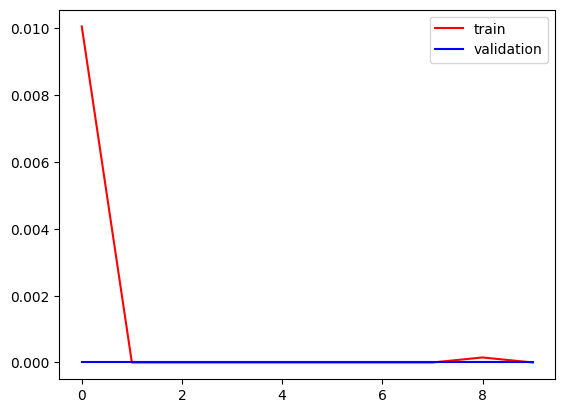

In [15]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
#overfitting

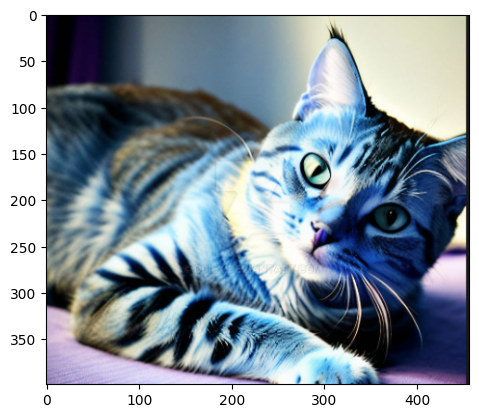

In [19]:
import cv2
import matplotlib.pyplot as plt

test_img = cv2.imread('/content/cat.png')   # correct extension
plt.imshow(test_img)
plt.show()

In [20]:
test_img.shape

(399, 457, 3)

In [21]:
test_img=cv2.resize(test_img,(256,256))

In [22]:
test_input=test_img.reshape((1,256,256,3))

In [23]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.]], dtype=float32)